## 1. Load and inspect data

In [2]:
import scanpy as sc
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

In [3]:
data_path = "../data/raw/rna.h5ad"
adata = ad.read_h5ad(data_path)

In [4]:
# Basic EDA for RNA-seq data
print("Number of cells:", adata.obs.shape[0])
print("Number of genes:", adata.var.shape[0])

Number of cells: 218331
Number of genes: 23712


In [5]:
# Number of perturbations and conditions
adata.obs.rename({"perturbation_2": "condition"}, axis=1, inplace=True)
print("Number of perturbations:", adata.obs['perturbation'].nunique())
print("Number of conditions:", adata.obs['condition'].nunique())

Number of perturbations: 249
Number of conditions: 3


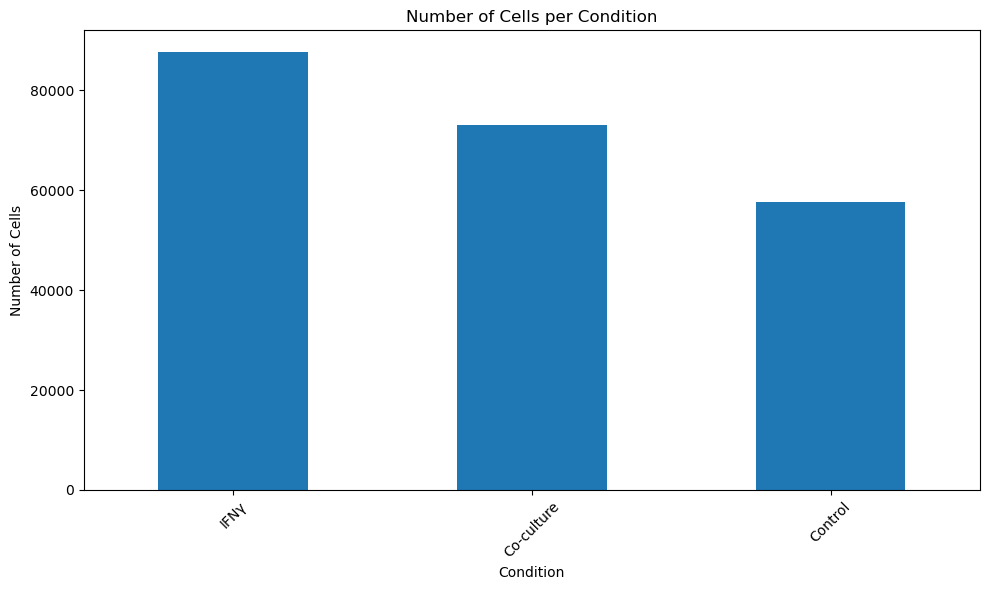

In [5]:
# Histogram of number of cells per condition
plt.figure(figsize=(10, 6))
condition_counts = adata.obs['condition'].value_counts()
condition_counts.plot(kind='bar')
plt.title('Number of Cells per Condition')
plt.xlabel('Condition')
plt.ylabel('Number of Cells')
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
adata.obs[adata.obs["perturbation"] == "HLA-B"]

,library_preparation_protocol,condition,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,perturbation_type,celltype,organism,perturbation_type_2,nperts,ngenes,ncounts,percent_mito,percent_ribo
cell_name,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3520,10832.0,3.618907,12.943131
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,5541,28821.0,4.250373,12.348635
CELL_57,10X 3' v3 sequencing,Control,3,nan,15383.0,HLA-B_1;TXNDC17_3;VDAC2_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4464,15383.0,3.159332,10.375089
CELL_523,10X 3' v3 sequencing,Control,2,nan,16244.0,HLA-B_3;KDR_1,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4489,16244.0,3.367397,12.564639
CELL_531,10X 3' v3 sequencing,Control,3,nan,31622.0,HLA-B_1;LINC00518_1;LINC00518_3,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,5494,31622.0,4.117387,18.948833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_216213,10X 3' v3 sequencing,Co-culture,1,HLA-B_3,19925.0,HLA-B_3,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4267,19925.0,6.092848,17.164366
CELL_216933,10X 3' v3 sequencing,Co-culture,1,HLA-B_3,7065.0,HLA-B_3,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,2430,7065.0,9.455060,14.706299
CELL_217051,10X 3' v3 sequencing,Co-culture,2,nan,7475.0,HLA-B_1;LCP1_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,2565,7475.0,6.220736,10.849498


## 2. Quality Control

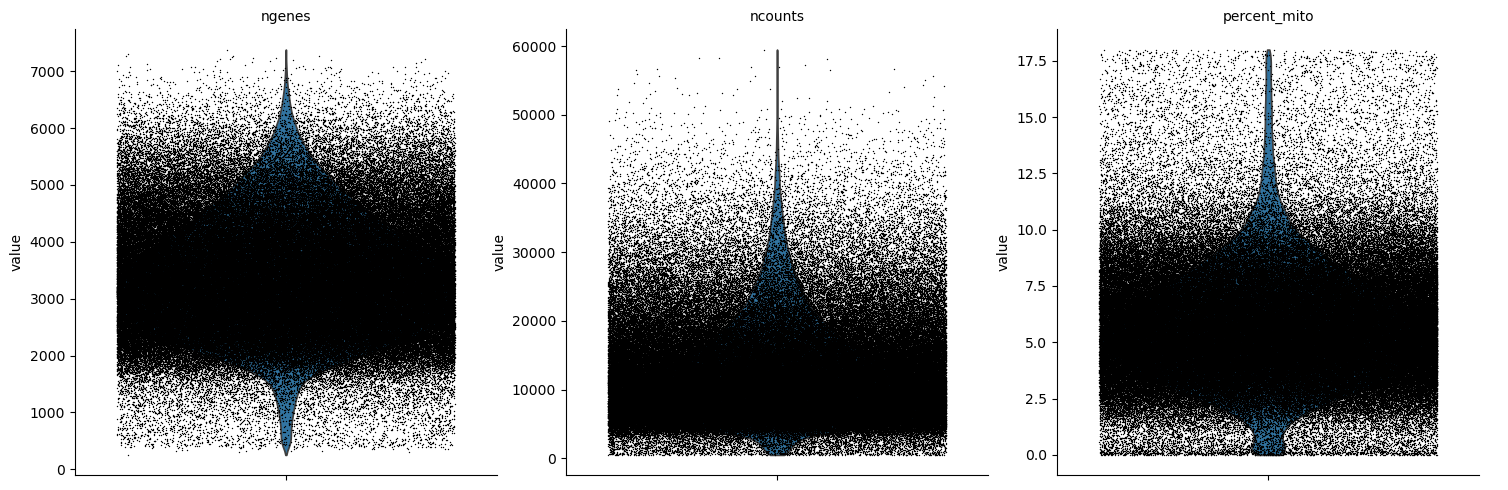

In [6]:
sc.pl.violin(
    adata,
    ["ngenes", "ncounts", "percent_mito"],
    jitter=0.4,
    multi_panel=True)

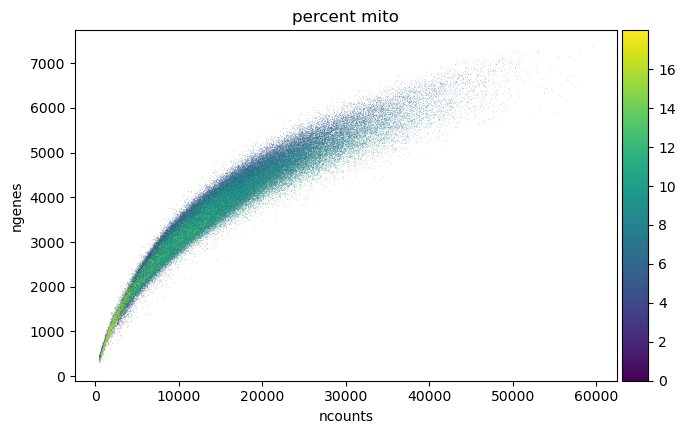

In [8]:
sc.pl.scatter(adata, "ncounts", "ngenes", color="percent_mito")